In [1]:
## Reference
# https://www.coursera.org/learn/introduction-computer-vision-watson-opencv

In [2]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import pandas as pd
# import tensorflow.compat.v1 as tf

2025-03-03 08:38:02.293464: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
from common_params import parent_directory_images, parent_directory_url_csvs
import importlib
import sys,os
import pandas as pd
from timethis import timethis



In [4]:

module_path='../02_preprocess_data/preprocess_data_fns.py'
spec = importlib.util.spec_from_file_location("preprocess_data_fns", module_path)
preprocess_data_fns = importlib.util.module_from_spec(spec)
sys.modules["preprocess_data_fns"] = preprocess_data_fns
spec.loader.exec_module(preprocess_data_fns)
preprocess_data_fns.process_image_files

/Users/levgolod/Projects/venv3/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<function preprocess_data_fns.process_image_files(input_files: list, image_size: int = 256) -> list>

In [12]:
IMAGE_SIZE = 512
label_dict = {v:k for k,v in preprocess_data_fns.body_style_dict.items()}
print(label_dict)
class_names = list(label_dict.values())
class_names

{0: 'sedan', 1: 'sportscar', 2: 'suv', 3: 'truck', 4: 'van', 5: 'wagon'}


['sedan', 'sportscar', 'suv', 'truck', 'van', 'wagon']

### Ingest image data from disk

In [6]:
output_filename_train_val_holdout = f'{parent_directory_url_csvs}df_train_val_hold.csv'
df=pd.read_csv(output_filename_train_val_holdout).sample(frac=1)
print(df.shape)
df.partition.value_counts(dropna=False,normalize=True)

(8775, 9)


partition
train    0.715442
hold     0.154758
val      0.129801
Name: proportion, dtype: float64

0 2025-03-03 08:39:30.364076
torch.Size([512, 512])
a1be8dc589804f049b8807c11afad26b.jpg; true label truck


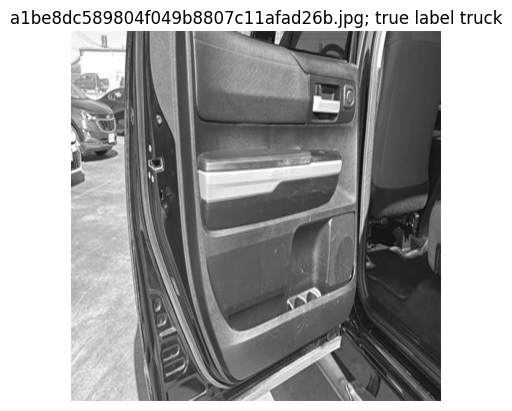

In [7]:
data_sample = df.head()[['filepath_to_use','body_style_index']].values
processed_images_sample = preprocess_data_fns.process_image_files(data_sample[:10], image_size=IMAGE_SIZE)

i=2
filename = os.path.basename(data_sample[i][0])
image_array = processed_images_sample[i][0].squeeze()
print(image_array.shape)
label = label_dict.get( processed_images_sample[i][1])
plt.imshow(image_array, cmap='gray')
plt.axis("off")
message=f"{filename}; true label {label}"
print(message)
plt.title(message)
plt.show()

In [8]:
train_dataset = preprocess_data_fns.process_image_files(
    df.loc[df['partition']=='train', ['filepath_to_use','body_style_index']].values,
    image_size=IMAGE_SIZE,
)

test_dataset = preprocess_data_fns.process_image_files(
    df.loc[df['partition']=='val', ['filepath_to_use','body_style_index']].values,
    image_size=IMAGE_SIZE,
)

holdout_dataset = preprocess_data_fns.process_image_files(
    df.loc[df['partition']=='hold', ['filepath_to_use','body_style_index']].values,
    image_size=IMAGE_SIZE,
)

print(len(train_dataset),len(test_dataset),len(holdout_dataset))

0 2025-03-03 08:39:34.111638
1000 2025-03-03 08:39:36.558280
2000 2025-03-03 08:39:39.163751
3000 2025-03-03 08:39:41.567572
4000 2025-03-03 08:39:43.978437
5000 2025-03-03 08:39:46.468642
6000 2025-03-03 08:39:49.003699
0 2025-03-03 08:39:49.708126
1000 2025-03-03 08:39:52.225921
0 2025-03-03 08:39:52.573654
1000 2025-03-03 08:39:55.099528
6278 1139 1358


In [11]:
train_images, train_labels = \
    [x[0] for x in train_dataset], [x[1] for x in train_dataset]

test_images, test_labels = \
    [x[0] for x in test_dataset], [x[1] for x in test_dataset]

holdout_images, holdout_labels = \
    [x[0] for x in holdout_dataset], [x[1] for x in holdout_dataset]

In [16]:
np.squeeze(train_images[0]).shape

torch.Size([512, 512])

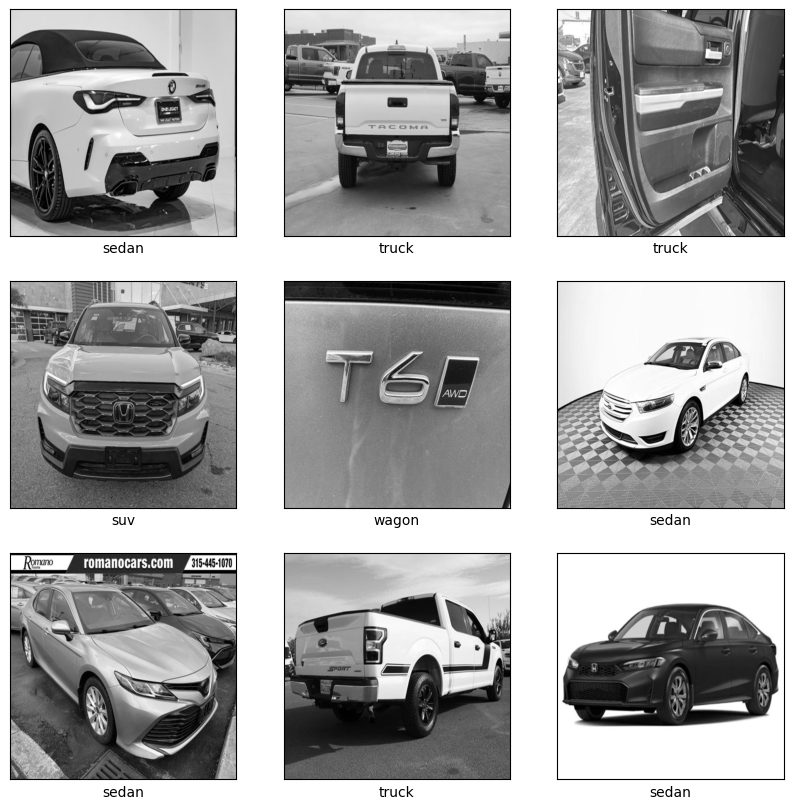

In [17]:
N=3
plt.figure(figsize=(10,10))
for i in range(N**2):
    plt.subplot(N,N,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(np.squeeze(train_images[i]), cmap='gray')
    # The CIFAR labels happen to be arrays,
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[i]])

plt.show()